<a href="https://colab.research.google.com/github/kailashscse2025-alt/DAA/blob/main/DAA6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


       MATRIX CHAIN MULTIPLICATION

Matrix Dimensions:
A1: 10 x 30
A2: 30 x 5
A3: 5 x 60
A4: 60 x 10

Minimum scalar multiplications:
5000

Optimal Parenthesization:
((A1 x A2) x (A3 x A4))

DP COST TABLE m[i][j]
                A1        A2        A3        A4
---------------------------------------------------------------------------
      A1         0      1500      4500      5000
      A2       ---         0      9000      4500
      A3       ---       ---         0      3000
      A4       ---       ---       ---         0


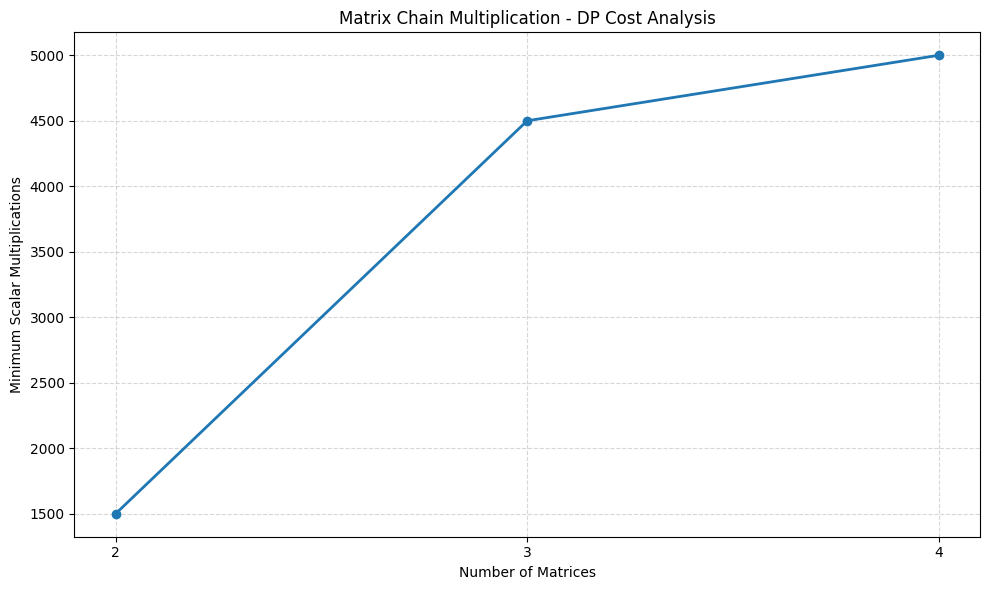

In [1]:
import matplotlib.pyplot as plt


# ==========================================
# MATRIX CHAIN MULTIPLICATION USING DP
# ==========================================

def matrix_chain_order(dims):
    """
    Matrix Chain Multiplication using Dynamic Programming

    dims: list of dimensions
    Matrix i has dimensions dims[i-1] x dims[i]

    Time Complexity: O(n^3)
    Space Complexity: O(n^2)
    """

    n = len(dims) - 1

    # m[i][j] = minimum number of multiplications
    m = [[0] * (n + 1) for _ in range(n + 1)]

    # s[i][j] = position of optimal split
    s = [[0] * (n + 1) for _ in range(n + 1)]

    # Chain length
    for length in range(2, n + 1):

        for i in range(1, n - length + 2):

            j = i + length - 1

            m[i][j] = float('inf')

            # Try every possible split
            for k in range(i, j):

                cost = (
                    m[i][k]
                    + m[k + 1][j]
                    + dims[i - 1] * dims[k] * dims[j]
                )

                if cost < m[i][j]:

                    m[i][j] = cost
                    s[i][j] = k

    return m, s


# ==========================================
# PRINT OPTIMAL PARENTHESIZATION
# ==========================================

def print_optimal_parens(s, i, j):

    if i == j:
        return f"A{i}"

    k = s[i][j]

    left = print_optimal_parens(s, i, k)
    right = print_optimal_parens(s, k + 1, j)

    return f"({left} x {right})"


# ==========================================
# PRINT DP TABLE
# ==========================================

def print_dp_table(m, n):

    print("\nDP COST TABLE m[i][j]")
    print("=" * 75)

    print(f"{'':>8}", end="")

    for j in range(1, n + 1):
        print(f"{'A' + str(j):>10}", end="")

    print()

    print("-" * 75)

    for i in range(1, n + 1):

        print(f"{'A' + str(i):>8}", end="")

        for j in range(1, n + 1):

            if j < i:
                print(f"{'---':>10}", end="")

            elif i == j:
                print(f"{'0':>10}", end="")

            else:
                print(f"{m[i][j]:>10}", end="")

        print()

    print("=" * 75)


# ==========================================
# MATRIX DIMENSIONS
# ==========================================

dims = [10, 30, 5, 60, 10]

n = len(dims) - 1


# ==========================================
# DISPLAY MATRIX DIMENSIONS
# ==========================================

print("\n==============================================")
print("       MATRIX CHAIN MULTIPLICATION")
print("==============================================")

print("\nMatrix Dimensions:")

for i in range(n):

    print(
        f"A{i + 1}: "
        f"{dims[i]} x {dims[i + 1]}"
    )


# ==========================================
# RUN DP
# ==========================================

m, s = matrix_chain_order(dims)


# ==========================================
# DISPLAY RESULT
# ==========================================

print("\nMinimum scalar multiplications:")
print(m[1][n])

print("\nOptimal Parenthesization:")
print(print_optimal_parens(s, 1, n))


# ==========================================
# DISPLAY DP TABLE
# ==========================================

print_dp_table(m, n)


# ==========================================
# GRAPH DATA
# ==========================================

# Minimum cost for different chain lengths
chain_lengths = []
minimum_costs = []

for length in range(2, n + 1):

    best_cost = float('inf')

    for i in range(1, n - length + 2):

        j = i + length - 1

        if m[i][j] < best_cost:
            best_cost = m[i][j]

    chain_lengths.append(length)
    minimum_costs.append(best_cost)


# ==========================================
# GRAPH
# ==========================================

plt.figure(figsize=(10, 6))

plt.plot(
    chain_lengths,
    minimum_costs,
    marker="o",
    linewidth=2
)

plt.xlabel("Number of Matrices")
plt.ylabel("Minimum Scalar Multiplications")

plt.title(
    "Matrix Chain Multiplication - DP Cost Analysis"
)

plt.xticks(chain_lengths)

plt.grid(
    True,
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()

plt.show()